# Lib

In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Config


In [6]:
from src.utils.config import *
from src.utils.preprocess_detection import (
    create_hog_positive_negative_patches,
    create_preprocessed_detection
)

# Raw
IMAGES_TRAIN = RAW_DETECTION_DIR / "images" / "train"
LABELS_TRAIN = RAW_DETECTION_DIR / "labels" / "train"

IMAGES_VAL = RAW_DETECTION_DIR / "images" / "validation"
LABELS_VAL = RAW_DETECTION_DIR / "labels" / "validation"

PATCH_SIZE = (64, 64)

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp"]

# Load Data

In [7]:
def load_detection_dataframe(images_dir, labels_dir, source_name):
    """
    Load image paths and corresponding YOLO label paths.

    Expected structure:
        images_dir/
            xxx.jpg
        labels_dir/
            xxx.txt

    Return:
        DataFrame with image_path, label_path, label_exists.
    """

    image_paths = []

    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(images_dir.glob(f"*{ext}"))

    image_paths = sorted(image_paths)

    records = []

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"

        records.append({
            "source": source_name,
            "image_name": image_path.name,
            "image_stem": image_path.stem,
            "image_path": str(image_path),
            "label_name": label_path.name,
            "label_path": str(label_path),
            "label_exists": label_path.exists()
        })

    df = pd.DataFrame(records)

    return df

In [8]:
raw_train_df = load_detection_dataframe(
    images_dir=IMAGES_TRAIN,
    labels_dir=LABELS_TRAIN,
    source_name="raw_train"
)

raw_validation_df = load_detection_dataframe(
    images_dir=IMAGES_VAL,
    labels_dir=LABELS_VAL,
    source_name="raw_validation"
)

print("Raw train images:", len(raw_train_df))
print("Raw validation images:", len(raw_validation_df))

display(raw_train_df.head())
display(raw_validation_df.head())

print("Raw train label exists:")
display(raw_train_df["label_exists"].value_counts())

print("Raw validation label exists:")
display(raw_validation_df["label_exists"].value_counts())

Raw train images: 26266
Raw validation images: 6573


,source,image_name,image_stem,image_path,label_name,label_path,label_exists
0,raw_train,0.jpeg,0,D:\image-processing-project\data\raw\face_dete...,0.txt,D:\image-processing-project\data\raw\face_dete...,True
1,raw_train,00006c07d2b033d1.jpg,00006c07d2b033d1,D:\image-processing-project\data\raw\face_dete...,00006c07d2b033d1.txt,D:\image-processing-project\data\raw\face_dete...,True
2,raw_train,0000bee39176697a.jpg,0000bee39176697a,D:\image-processing-project\data\raw\face_dete...,0000bee39176697a.txt,D:\image-processing-project\data\raw\face_dete...,True
3,raw_train,0000eda1171fe14e.jpg,0000eda1171fe14e,D:\image-processing-project\data\raw\face_dete...,0000eda1171fe14e.txt,D:\image-processing-project\data\raw\face_dete...,True
4,raw_train,00090bdd55ec42c3.jpg,00090bdd55ec42c3,D:\image-processing-project\data\raw\face_dete...,00090bdd55ec42c3.txt,D:\image-processing-project\data\raw\face_dete...,True


,source,image_name,image_stem,image_path,label_name,label_path,label_exists
0,raw_validation,0.jpeg,0,D:\image-processing-project\data\raw\face_dete...,0.txt,D:\image-processing-project\data\raw\face_dete...,True
1,raw_validation,0003d5dfa8f0dd41.jpg,0003d5dfa8f0dd41,D:\image-processing-project\data\raw\face_dete...,0003d5dfa8f0dd41.txt,D:\image-processing-project\data\raw\face_dete...,True
2,raw_validation,0007ad5c6245a41d.jpg,0007ad5c6245a41d,D:\image-processing-project\data\raw\face_dete...,0007ad5c6245a41d.txt,D:\image-processing-project\data\raw\face_dete...,True
3,raw_validation,000cc0cd61c6c8d7.jpg,000cc0cd61c6c8d7,D:\image-processing-project\data\raw\face_dete...,000cc0cd61c6c8d7.txt,D:\image-processing-project\data\raw\face_dete...,True
4,raw_validation,001ea8a8ca78a3bc.jpg,001ea8a8ca78a3bc,D:\image-processing-project\data\raw\face_dete...,001ea8a8ca78a3bc.txt,D:\image-processing-project\data\raw\face_dete...,True


Raw train label exists:


label_exists
True    26266
Name: count, dtype: int64

Raw validation label exists:


label_exists
True    6573
Name: count, dtype: int64

## Visual check one sample

In [9]:
def read_image(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Cannot read image: {image_path}")

    return image


def clamp_bbox_xyxy(bbox, image_width, image_height):
    x1, y1, x2, y2 = bbox

    x1 = max(0, min(int(round(x1)), image_width - 1))
    y1 = max(0, min(int(round(y1)), image_height - 1))
    x2 = max(0, min(int(round(x2)), image_width))
    y2 = max(0, min(int(round(y2)), image_height))

    if x2 <= x1:
        x2 = min(image_width, x1 + 1)

    if y2 <= y1:
        y2 = min(image_height, y1 + 1)

    return x1, y1, x2, y2


def yolo_to_xyxy(x_center, y_center, box_width, box_height, image_width, image_height):
    values = [x_center, y_center, box_width, box_height]

    # YOLO normalized
    if max(values) <= 1.5:
        x_center *= image_width
        y_center *= image_height
        box_width *= image_width
        box_height *= image_height

    x1 = x_center - box_width / 2
    y1 = y_center - box_height / 2
    x2 = x_center + box_width / 2
    y2 = y_center + box_height / 2

    return clamp_bbox_xyxy(
        bbox=(x1, y1, x2, y2),
        image_width=image_width,
        image_height=image_height
    )


def read_yolo_label_file(label_path, image_width, image_height):
    label_path = Path(label_path)

    if not label_path.exists():
        return []

    boxes = []

    with open(label_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    for line in lines:
        line = line.strip()

        if line == "":
            continue

        parts = line.split()

        if len(parts) < 5:
            continue

        x_center = float(parts[1])
        y_center = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])

        box = yolo_to_xyxy(
            x_center=x_center,
            y_center=y_center,
            box_width=box_width,
            box_height=box_height,
            image_width=image_width,
            image_height=image_height
        )

        boxes.append(box)

    return boxes


def draw_boxes(image, boxes, color=(0, 255, 0), thickness=2):
    output = image.copy()

    for box in boxes:
        x1, y1, x2, y2 = box

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            color,
            thickness
        )

    return output

Sample image: D:\image-processing-project\data\raw\face_detection\images\train\3f154ef1af6a7315.jpg
Sample label: D:\image-processing-project\data\raw\face_detection\labels\train\3f154ef1af6a7315.txt
Image size: 835 1024
Number of boxes: 1
Boxes: [(131, 212, 579, 669)]


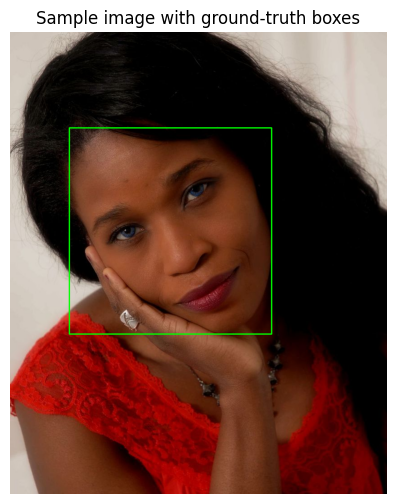

In [10]:
sample_row = raw_train_df.sample(1).iloc[0]

sample_image_path = Path(sample_row["image_path"])
sample_label_path = Path(sample_row["label_path"])

image = read_image(sample_image_path)
height, width = image.shape[:2]

boxes = read_yolo_label_file(
    label_path=sample_label_path,
    image_width=width,
    image_height=height
)

print("Sample image:", sample_image_path)
print("Sample label:", sample_label_path)
print("Image size:", width, height)
print("Number of boxes:", len(boxes))
print("Boxes:", boxes[:5])

vis = draw_boxes(image, boxes)
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(vis_rgb)
plt.axis("off")
plt.title("Sample image with ground-truth boxes")
plt.show()

## Train/Val/Test split

In [11]:
train_df = raw_train_df.copy()

val_df, test_df = train_test_split(
    raw_validation_df,
    train_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))

Train images: 26266
Val images: 3286
Test images: 3287


# Preprocessing

## Haar Cascade

In [12]:
val_full_records, val_full_summary = create_preprocessed_detection(
    df=val_df,
    output_dir=VAL_DETECTION,
    gamma=1.0,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8),
    image_ext=".png"
)

val_full_summary

{'total_images_saved': 3286,
 'total_labels_saved': 3286,
 'total_missing_labels': 0,
 'total_failed': 0}

In [13]:
test_full_records, test_full_summary = create_preprocessed_detection(
    df=test_df,
    output_dir=TEST_DETECTION,
    gamma=1.0,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8),
    image_ext=".png"
)

test_full_summary

{'total_images_saved': 3287,
 'total_labels_saved': 3287,
 'total_missing_labels': 0,
 'total_failed': 0}

## Crop positive / negative cho HOG SVM

In [14]:
train_records, train_summary = create_hog_positive_negative_patches(
    df=train_df,
    output_dir=TRAIN_DETECTION,
    patch_size=PATCH_SIZE,
    gamma=1.0,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8),
    positive_padding=0.15,
    negative_per_face=2,
    negative_iou_threshold=0.1
)

train_summary

{'total_positive': 200967, 'total_negative': 292575, 'total_failed': 0}

In [15]:
val_records, val_summary = create_hog_positive_negative_patches(
    df=val_df,
    output_dir=VAL_DETECTION,
    patch_size=PATCH_SIZE,
    gamma=1.0,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8),
    positive_padding=0.15,
    negative_per_face=2,
    negative_iou_threshold=0.1
)

val_summary

{'total_positive': 24892, 'total_negative': 36029, 'total_failed': 0}